Import des Bibliothèques 

In [99]:
!pip install pytz
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [119]:
# Ajouter les fonction de data cleaning dans cette feuille 

#Bibliothèques 
import pandas as pd 
print(pd.__version__)
import numpy as np 
from io import StringIO
from zoneinfo import ZoneInfo
import os
import matplotlib.pyplot as plt

print ("librairies importées")


3.0.1
librairies importées


Code Ana 

Nettoyage des données day ahead prices pour 2024 2025

[Day-ahead Prices_2024-2025.csv] ✅ Aucune valeur manquante.
Dimensions : (8784, 3)
count    8784.000000
mean       58.019464
std        40.658254
min       -87.290000
25%        25.507500
50%        58.810000
75%        86.537500
max       284.210000
Name: Day-ahead Price (EUR/MWh), dtype: float64


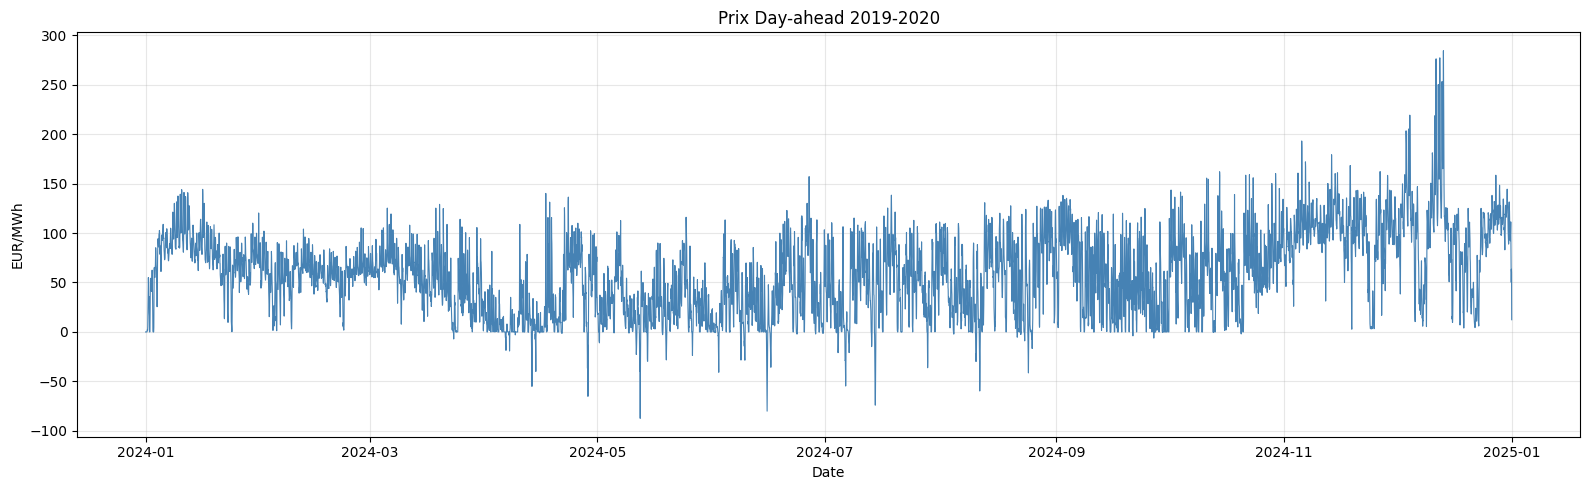

In [138]:
def harmonize_data_DayAhead_price(chemin_fichier):
    try:
        with open(chemin_fichier, 'r', encoding='utf-8') as f:
            raw_lines = f.readlines()

        cleaned_lines = []
        for line in raw_lines:
            line = line.strip()
            if line.startswith('"') and line.endswith('"'):
                line = line[1:-1]
            line = line.replace('""', '"')
            cleaned_lines.append(line)

        df = pd.read_csv(StringIO("\n".join(cleaned_lines)), sep=',', quotechar='"')
        df.columns = df.columns.str.strip()

    except Exception as e:
        print("Erreur lors de la lecture :", e)
        return None

    try:
        df = df[["MTU (UTC)", "Day-ahead Price (EUR/MWh)"]].copy()
        df[["Date_start", "Date_end"]] = df["MTU (UTC)"].str.split(" - ", expand=True)
        df = df.drop(columns=["MTU (UTC)"])
        df["Date_start"] = pd.to_datetime(df["Date_start"], format="%d/%m/%Y %H:%M:%S", errors='coerce')
        df["Date_end"]   = pd.to_datetime(df["Date_end"],   format="%d/%m/%Y %H:%M:%S", errors='coerce')
        df["Date_start"] = df["Date_start"].dt.tz_localize("UTC")
        df["Date_end"]   = df["Date_end"].dt.tz_localize("UTC")
        df["Day-ahead Price (EUR/MWh)"] = pd.to_numeric(df["Day-ahead Price (EUR/MWh)"], errors='coerce')
        df = df[["Date_start", "Date_end", "Day-ahead Price (EUR/MWh)"]]
    except Exception as e:
        print("Erreur lors du traitement :", e)
        return None
    
    # df = df.drop_duplicates(subset='Date_start', keep='first')

    nb_manquants = df.isnull().sum()
    nom_fichier = os.path.basename(chemin_fichier)
    if nb_manquants.any():
        print(f"[{nom_fichier}] ⚠️  Valeurs manquantes :")
        print(nb_manquants[nb_manquants > 0])
        print(df[df.isnull().any(axis=1)])
    else:
        print(f"[{nom_fichier}] ✅ Aucune valeur manquante.")

    return df


# Tests
path = "./Data/Day-ahead Prices_2024-2025.csv"
df_clean = harmonize_data_DayAhead_price(path)
print(f"Dimensions : {df_clean.shape}")
print(df_clean["Day-ahead Price (EUR/MWh)"].describe())

plt.figure(figsize=(16, 5))
plt.plot(df_clean["Date_start"], df_clean["Day-ahead Price (EUR/MWh)"], linewidth=0.8, color="steelblue")
plt.title("Prix Day-ahead 2019-2020")
plt.ylabel("EUR/MWh")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


[Day-ahead Prices_2019-2020.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
count    8760.000000
mean       39.449507
std        14.022041
min       -24.920000
25%        31.000000
50%        38.650000
75%        47.430000
max       121.460000
Name: Day-ahead Price (EUR/MWh), dtype: float64
Date min : 2019-01-01 00:00:00+00:00
Date max : 2019-12-31 23:00:00+00:00


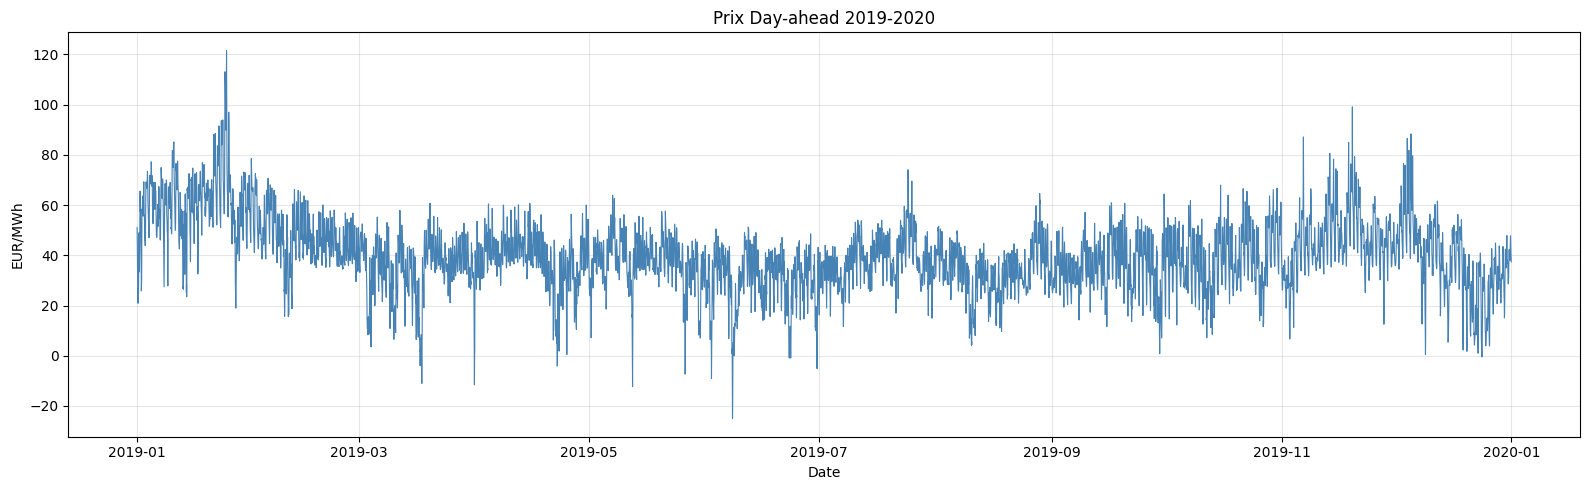

In [140]:
def clean_previous_data_prices(chemin_fichier):
    try:
        df = pd.read_csv(chemin_fichier)
        df = df.rename(columns={"Day-ahead Price [EUR/MWh]": "Day-ahead Price (EUR/MWh)"})
        df = df.drop(columns=[c for c in ["BZN|FR", "Currency", "MTU (CET/CEST)"] if c in df.columns])

        # Conversion du prix en float et suppression des NaN
        df["Day-ahead Price (EUR/MWh)"] = pd.to_numeric(df["Day-ahead Price (EUR/MWh)"], errors='coerce')
        df = df.dropna(subset=["Day-ahead Price (EUR/MWh)"]).reset_index(drop=True)

        # Détecter l'année de début depuis le nom du fichier
        annee_debut = os.path.basename(chemin_fichier).split("_")[-1][:4]

        # Générer les dates UTC
        df["Date_start"] = pd.date_range(start=f"{annee_debut}-01-01 00:00:00", periods=len(df), freq="h", tz="UTC")
        df["Date_end"]   = pd.date_range(start=f"{annee_debut}-01-01 01:00:00", periods=len(df), freq="h", tz="UTC")

        df = df[["Date_start", "Date_end", "Day-ahead Price (EUR/MWh)"]]

    except Exception as e:
        print("Erreur :", e)
        return None

    nom_fichier = os.path.basename(chemin_fichier)
    nb_manquants = df.isnull().sum()
    if nb_manquants.any():
        print(f"[{nom_fichier}] ⚠️  Valeurs manquantes :")
        print(nb_manquants[nb_manquants > 0])
    else:
        print(f"[{nom_fichier}] ✅ Aucune valeur manquante.")

    nb_doublons = df.duplicated(subset='Date_start').sum()
    print(f"Doublons : {nb_doublons}")
    print(f"Dimensions : {df.shape}")

    return df

path2 = "./Data/Day-ahead Prices_2019-2020.csv"
df_clean2 = clean_previous_data_prices(path2)
print(df_clean2["Day-ahead Price (EUR/MWh)"].describe())
print(f"Date min : {df_clean2['Date_start'].min()}")
print(f"Date max : {df_clean2['Date_start'].max()}")



plt.figure(figsize=(16, 5))
plt.plot(df_clean2["Date_start"], df_clean2["Day-ahead Price (EUR/MWh)"], linewidth=0.8, color="steelblue")
plt.title("Prix Day-ahead 2019-2020")
plt.ylabel("EUR/MWh")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [68]:

# Marie : Prix de l'énergie sur le marché SPOT
def clean_data_price (chemin_fichier):
    df = pd.read_csv(chemin_fichier)
    if df["BZN|FR"].isna().all(): # on vérifie que la colonne est vide avant de la supprimer
        df = df.drop(columns=["BZN|FR"])
        print('La colonne "BZN|FR" était vide et a été supprimée.')
    else:
        print('La colonne "BZN|FR" contient des données.')
    df=df.drop(columns=["Currency"])
    df[["Date_start", "Date_end"]] = df["MTU (CET/CEST)"].str.split(" - ", expand=True) 
    df = df.drop(columns=["MTU (CET/CEST)"]) # on supprime l'ancienne colonne de la plage horaire
    df["Date_start"] = pd.to_datetime(df["Date_start"], format="%d.%m.%Y %H:%M", utc = True).dt.tz_localize(None) # on change de le format de la date de début et de fin
    df["Date_end"] = pd.to_datetime(df["Date_end"], format="%d.%m.%Y %H:%M", utc = True).dt.tz_localize(None) # on change de le format de la date de fin
    print(df.shape)
    print(df.head())
    return df
#clean_data_price(".\Data\Day-ahead Prices_2019-2020.csv")



In [ ]:
# Marine : Température & pseudo rayonnement
def clean_data_temperature (chemin_fichier): 
    fichier = pd.read_csv(chemin_fichier, sep=";")
    fichier["Horodate"] = pd.to_datetime(fichier["Horodate"], utc = True)
    fichier = fichier.drop(columns=["Année-Mois-Jour"])
    fichier = fichier.drop(columns = ["Année"])
    fichier = fichier.drop(columns = ["Mois"])
    fichier = fichier.drop(columns = ["Jour"])
    print(fichier.isna().sum())
    print(fichier.isnull().sum() )
    print(fichier.duplicated().sum())
    print(fichier.info())
    print(fichier.head())
    print(fichier.describe()) 
    return fichier

  

Création d'un dataframe avec l'ensemble des data "day ahead prices" depuis 2019


Période : 2019-2020
[Day-ahead Prices_2019-2020.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Lignes     : 8760
  Date min   : 2019-01-01 00:00:00+00:00
  Date max   : 2019-12-31 23:00:00+00:00

Période : 2020-2021
[Day-ahead Prices_2020-2021.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8784, 3)
  Lignes     : 8784
  Date min   : 2020-01-01 00:00:00+00:00
  Date max   : 2020-12-31 23:00:00+00:00

Période : 2021-2022
[Day-ahead Prices_2021-2022.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Lignes     : 8760
  Date min   : 2021-01-01 00:00:00+00:00
  Date max   : 2021-12-31 23:00:00+00:00

Période : 2022-2023
[Day-ahead Prices_2022-2023.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Lignes     : 8760
  Date min   : 2022-01-01 00:00:00+00:00
  Date max   : 2022-12-31 23:00:00+00:00

Période : 2023-2024
[Day-ahead Prices_2023-2024.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Ligne

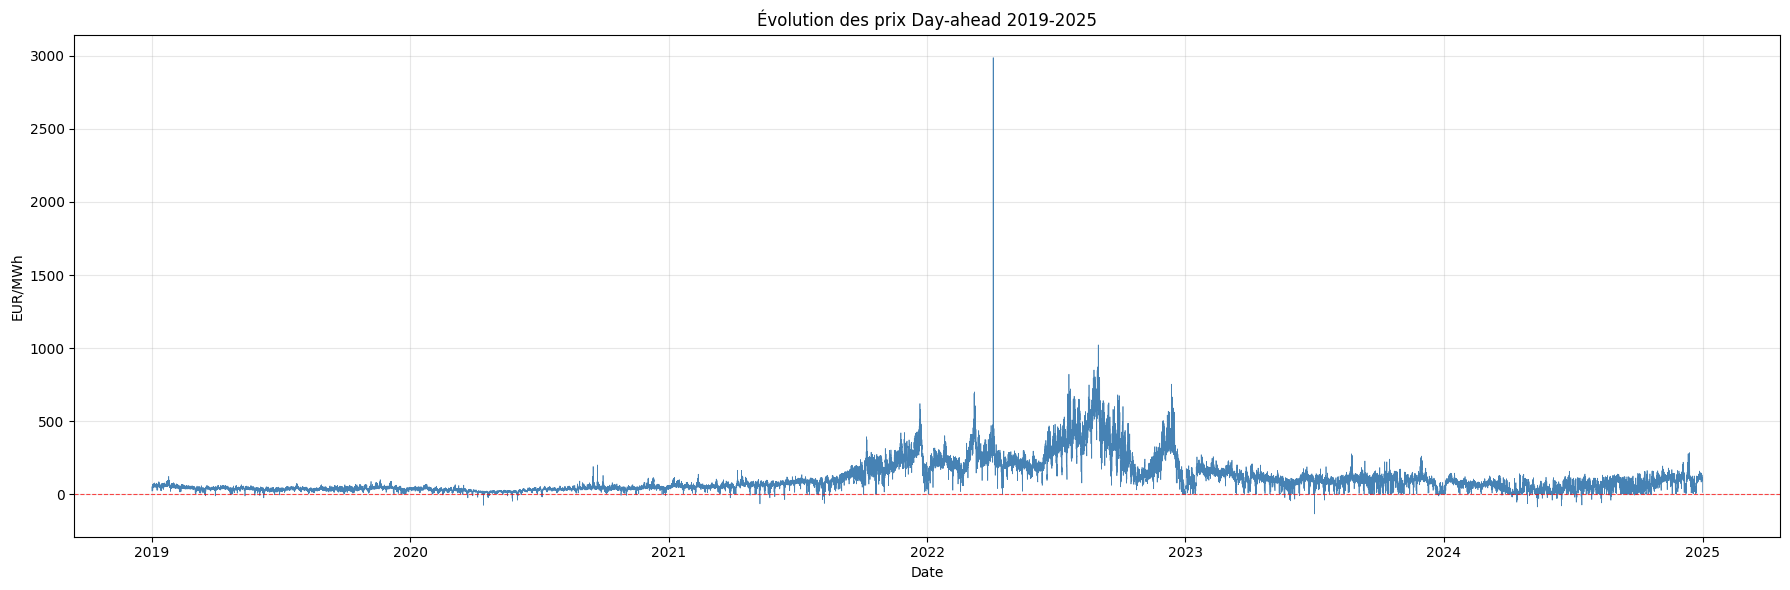

In [142]:
paths = {
    "2019-2020": r".\Data\Day-ahead Prices_2019-2020.csv",
    "2020-2021": r".\Data\Day-ahead Prices_2020-2021.csv",
    "2021-2022": r".\Data\Day-ahead Prices_2021-2022.csv",
    "2022-2023": r".\Data\Day-ahead Prices_2022-2023.csv",
    "2023-2024": r".\Data\Day-ahead Prices_2023-2024.csv",
    "2024-2025": r".\Data\Day-ahead Prices_2024-2025.csv",
}

dfs = {}

for periode, chemin in paths.items():
    print(f"\n{'='*40}")
    print(f"Période : {periode}")

    if periode == "2024-2025":
        df = harmonize_data_DayAhead_price(chemin)
    else:
        df = clean_previous_data_prices(chemin)

    if df is None:
        print(f"  ⚠️  Échec du chargement pour {periode}")
        continue

    print(f"  Lignes     : {len(df)}")
    print(f"  Date min   : {df['Date_start'].min()}")
    print(f"  Date max   : {df['Date_start'].max()}")

    dfs[periode] = df

# Concaténation
print(f"\n{'='*40}")
print("Concaténation de tous les DataFrames...")

df_all = pd.concat(dfs.values())
# df_all = df_all.sort_values("Date_start").reset_index(drop=True)

print(f"Dimensions totales : {df_all.shape}")
# print(f"Date min           : {df_all['Date_start'].min()}")
# print(f"Date max           : {df_all['Date_start'].max()}")
print(f"Valeurs manquantes :\n{df_all.isnull().sum().to_string()}")
# print(f"Doublons           : {df_all.duplicated(subset='Date_start').sum()}")
nb_doublons = df_all.duplicated(subset='Date_start').sum()
print(f"Doublons           : {nb_doublons}")
if nb_doublons > 0:
    print(df_all[df_all.duplicated(subset='Date_start', keep=False)].sort_values("Date_start"))
print(df_all.head())

print(df_all["Day-ahead Price (EUR/MWh)"].describe())

# Graphique evolution des prix
df_plot = df_all.sort_values("Date_start").dropna(subset=["Date_start", "Day-ahead Price (EUR/MWh)"])

plt.figure(figsize=(18, 6))
plt.plot(df_plot["Date_start"], df_plot["Day-ahead Price (EUR/MWh)"], linewidth=0.5, color="steelblue")
plt.title("Évolution des prix Day-ahead 2019-2025")
plt.ylabel("EUR/MWh")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)

# Ligne horizontale à 0 pour repérer les prix négatifs
plt.axhline(y=0, color='red', linewidth=0.8, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()